In [1]:
import os
import pickle
import numpy as np
import nibabel as nib
from cortex import mni
import cortex

In [ ]:
# file = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/105/code_formatted_keystrokes.pkl"
# with open(file, 'rb') as f:
#     keys = pickle.load(f)

In [2]:
atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx]
cortex_vx = np.where(atlas_only_brain != 0)[0]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)
    
# def create_histogram(voxcorrs):
#     f = plt.figure(figsize=(8,8))
#     ax = f.add_subplot(1,1,1)
#     ax.hist(voxcorrs, 100) # histogram correlations with 100 bins
#     ax.set_xlabel("Correlation")
#     ax.set_ylabel("Num. voxels");
#     plt.savefig() # TODO

def convert_to_nifti(values):
    # working backwards to save correlation values as voxels in MNI space
    empty_schaefer[cortex_vx] = values
    empty_mni[brain_idx] = empty_schaefer
    result_brain = np.reshape(empty_mni, og_shape)

    # Saving results
    nifti_result = nib.Nifti1Image(result_brain, affine=atlas.affine, header=atlas.header)
    # nib.save(nifti_result, "test_plotting.nii.gz")
    return result_brain, nifti_result

In [3]:
# filepath = "/storage1/fmri_model_data/ridge_regression_pca_models/111/codegemma_7b-layer_28-code-correlations.pkl"
filepath = "/storage1/fmri_model_data/ridge_regression_pca_models/122/deepseek_2b-layer_18-code-correlations.pkl"
with open(filepath, 'rb') as f:
    data = pickle.load(f)

npy_brain, nifti_brain = convert_to_nifti(data)

In [4]:
nii = nib.load("test_plotting.nii.gz")
data = nii.get_fdata()

In [11]:
subject = 'fsaverage'
xfmname = 'mni2func'

from cortex import xfm

In [5]:
mni = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases/MNI152_T1_2mm_brain.nii.gz"
# anat = "/storage1/fmri_model_data/midprocess/111/Warped.nii.gz"
anat = "/storage1/fmri_model_data/midprocess/122/Warped.nii.gz"

# os.system(f"flirt -in {anat} -ref {mni} -out test_registered -omat affine.mat")

In [7]:
cortex.freesurfer.import_subj(freesurfer_subject='sub-111', pycortex_subject='sub-111')

b'created by zachkaras on Tue Dec 16 19:43:02 2025\n'
b'created by zachkaras on Tue Dec 16 20:57:42 2025\n'
b'created by zachkaras on Tue Dec 16 19:43:06 2025\n'
b'created by zachkaras on Tue Dec 16 21:02:37 2025\n'


In [9]:
test = cortex.mni.compute_mni_transform(subject='sub-111', xfm='identity', template=mni)

Generating brainmask anatomical...
Brain masking anatomical...
Calling: bet /home/zachkaras/miniconda3/share/pycortex/db/sub-111/anatomicals/raw.nii.gz /home/zachkaras/miniconda3/share/pycortex/db/sub-111/anatomicals/brainmask.nii.gz -B -v
IN=/home/zachkaras/miniconda3/share/pycortex/db/sub-111/anatomicals/raw
OUT=/home/zachkaras/miniconda3/share/pycortex/db/sub-111/anatomicals/brainmask
bet2opts= -v
verbose=1
debug=0
variation=7
IN=/home/zachkaras/miniconda3/share/pycortex/db/sub-111/anatomicals/brainmask_tmp_unbiased_premask
OUT=/home/zachkaras/miniconda3/share/pycortex/db/sub-111/anatomicals/brainmask
bet2opts= -m -v
verbose=1
debug=1
variation=1
min 0 thresh2 0 thresh 9.80953 thresh98 98.0953 max 272.487
c-of-g 131.622 103.61 105.652 mm
radius 76.2803 mm
median within-brain intensity 56.6537
self-intersection total 2910.59 (threshold=4000.0) 
min 0 thresh2 0 thresh 9.80953 thresh98 98.0953 max 272.487
c-of-g 131.481 93.4039 106.303 mm
radius 76.2803 mm
median within-brain intensity

In [ ]:
cortex.db.save_xfm(subject='sub-111', name='sub-111', xfm=test, reference=mni)

ValueError: Please specify a reference

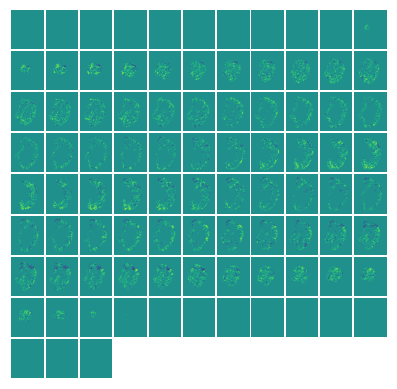

In [5]:
test = cortex.mosaic(data)

In [13]:
vol = cortex.Volume(
    data,
    subject='fsaverage',
    xfmname='atlas_2mm',
)

Generating a flatmap cache


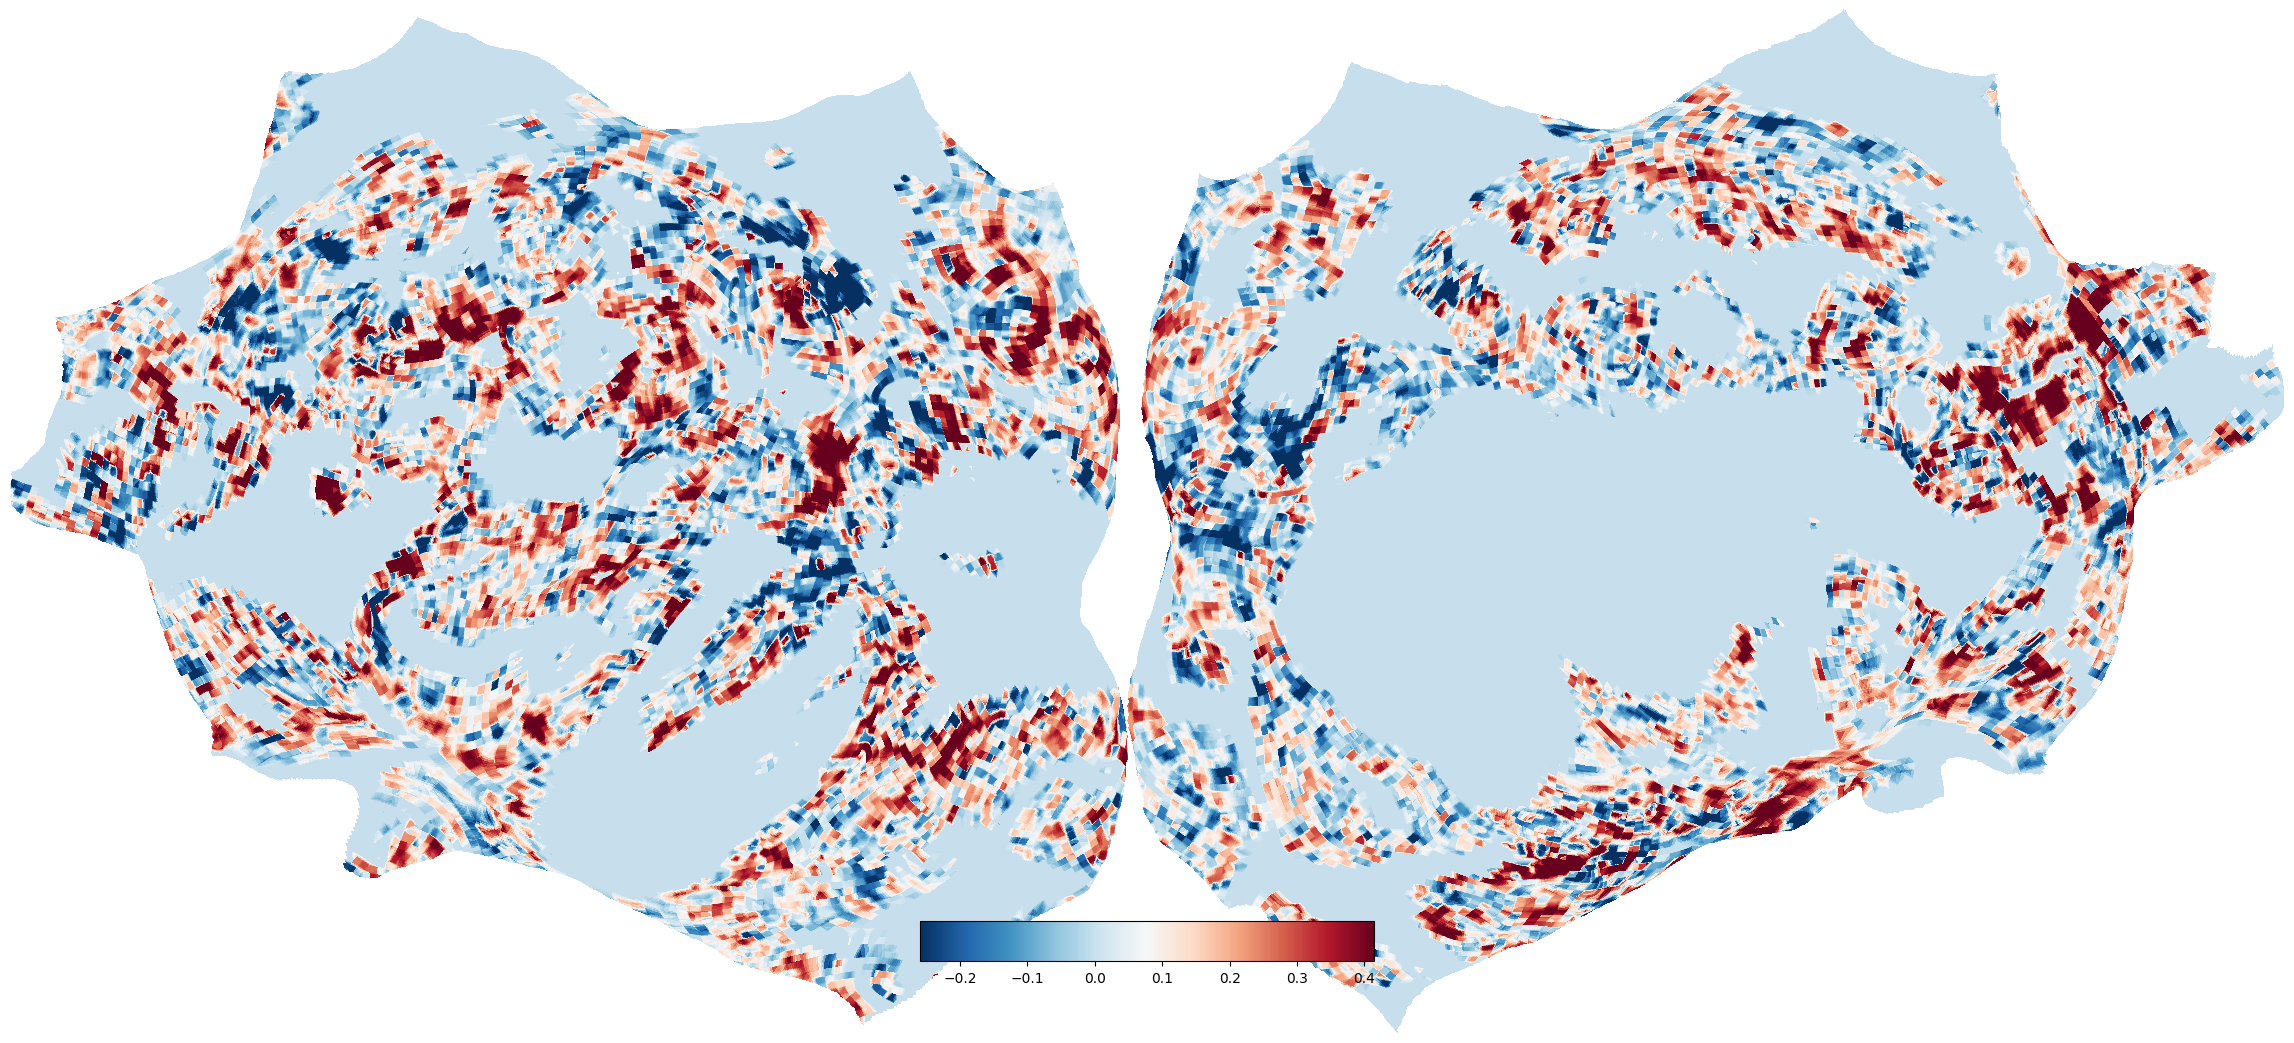

In [11]:
from cortex.quickflat import make_figure

fig = make_figure(
    vol,
    with_rois=False,
    with_labels=False,
    with_sulci=False,
    with_borders=True,
    thick=5
)

In [ ]:
# cortex.webshow(vol)
cortex.webshow(vol)
# cortex.quickshow(vol, with_labels=False)

Started server on port 64243


<JS: window.viewer>

Stopping server


In [ ]:
# import scipy.io as sio

mat = np.loadtxt("affine.mat")
func = "test_plotting.nii.gz"

test = xfm.Transform.from_fsl(xfm=xfm, anat_nii=anat, func_nii=func)
# test = xfm.Transform()
# need xfm and reference

AttributeError: 'numpy.ndarray' object has no attribute 'Transform'

In [18]:
mni.compute_mni_transform(
    subject='test',
    xfm = 'identity',
)

KeyError: 'test'

In [11]:
surf = mni.transform_mni_to_subject(
    data = nii.get_fdata(),
    affine = nii.affine,
    subject = 'fsaverage',
    target = 'surface'
)

TypeError: transform_mni_to_subject() got an unexpected keyword argument 'data'

In [14]:
dir(cortex.surfs)

/home/zachkaras/fsl/lib/python3.11/site-packages/cortex/__init__.py:38: Warning: cortex.surfs is deprecated, use cortex.db instead
  warnings.warn("cortex.surfs is deprecated, use cortex.db instead", Warning)


['S1',
 'get_anat',
 'get_cache',
 'get_mask',
 'get_mnixfm',
 'get_mri_surf2surf_matrix',
 'get_overlay',
 'get_surf',
 'get_surfinfo',
 'get_view',
 'get_xfm',
 'save_view',
 'save_xfm',
 'subjects']

In [4]:
mni_data = nifti_brain.get_fdata()
mni_affine = nifti_brain.affine

In [ ]:
# import cortex
from cortex import mni

# subject: Any,
#     xfm: Any,
#     volarray: Any,
#     func_to_mni: Any,
#     template: str = default_template

vol = mni.transform_mni_to_subject(
    data=mni_data,
    subject='fsaverage',
    affine=mni_affine
)

TypeError: transform_mni_to_subject() got an unexpected keyword argument 'data'

In [30]:
# Plot mosaic of correlations
from matplotlib.pyplot import figure, cm
import matplotlib.pyplot as plt
# corrvolume = np.zeros(mask.shape)
# corrvolume[mask>0] = voxcorrs

voxel_vol = cortex.Volume(npy_brain, "test", "fullhead")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper("test", "fullhead", 'line_nearest', recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol)
plt.show()
cortex.quickshow(vertex_map)
plt.show()

# f = figure(figsize=(10,10))
# cortex.mosaic(npy_brain, vmin=0, vmax=0.5, cmap=cm.hot);

# Create a cortex.Volume object from the NumPy array
# You can specify colormap, vmin, vmax, and a description
# volume_data = cortex.Volume(npy_brain, "test", "test",
#                             cmap='viridis', vmin=0, vmax=1,
#                             description='Example NumPy array plot')

# # Display the volume data using quickshow
# cortex.quickshow(volume_data)

# You can also save the visualization as a web page
# cortex.webshow(volume_data, filename='numpy_array_plot.html')

FileNotFoundError: [Errno 2] No such file or directory: '/home/zachkaras/miniconda3/share/pycortex/db/test/transforms/fullhead/matrices.xfm'

In [7]:
import cortex
# nifti_img = nib.load("/storage1/fmri_model_data/ridge_regression_pca_models/111/codegemma_7b-layer_28-prose-correlations.pkl")
# data = nifti_img.get_fdata()
vol_data = cortex.Volume(nifti)

NameError: name 'nifti' is not defined

In [ ]:
import cortex
import nibabel as nib
# Load the NIFTI file: Use nibabel to load your NIFTI image.
# Python

nifti_img = nib.load('your_nifti_file.nii.gz')
data = nifti_img.get_fdata()
# Create a cortex.Volume object: This object encapsulates your volumetric data and its spatial information. You need to provide the data, a subject ID, and a transform name (which defines how the volume aligns with the surface).
# Python

# Assuming 'subject_id' and 'transform_name' are already defined in your pycortex database
# For example, if you have a subject 'S1' and a transform 'func_to_anat'
volume_data = cortex.Volume(data, 'subject_id', 'transform_name')
# Plot the data on the flatmap: Use cortex.quickflat.make_figure to generate a flatmap visualization of your data.
# Python

cortex.quickflat.make_figure(volume_data, with_colorbar=True)